In [2]:
def merge_two_lists(l1, l2):
    x1, y1 = l1
    x2, y2 = l2
    x_ = x1+x2
    y_ = y1+y2
    xy_dict = {}
    for x, y in zip(x_, y_):
        if x in xy_dict:
            xy_dict[x].append(y)
        else:
            xy_dict[x] = [y]
    
    x_sorted = []
    y_sorted = []
    for x in sorted(xy_dict.keys()):
        x_sorted.append(x)
        avg_y = sum(xy_dict[x]) / len(xy_dict[x])
        y_sorted.append(avg_y)
    
    return x_sorted, y_sorted

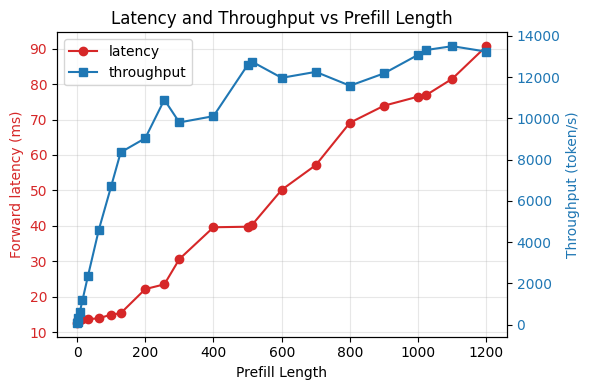

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# extend_profiling
# bs1 = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
# latency1 = [16.014, 16.933, 16.989, 17.231, 17.221, 17.351, 17.778, 19.939, 30.242, 55.317, 107.531]
# bs2 = [1]
# bs2.extend(list(range(100, 1001, 100)))
# latency2 = [16.037, 18.858, 27.885, 38.965, 50.315, 54.878, 69.040, 79.183, 94.377, 124.422, 106.990]
# bs, latency = merge_two_lists((bs1, latency1), (bs2, latency2))
# throughput = [bs[i] / latency[i] * 1000 for i in range(len(bs))]
# x_label = 'Batch Size'
# x = bs

# prefill_profiling
ps1 = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
latency1 = [12.640, 13.811, 13.539, 13.551, 13.573, 13.638, 13.915, 15.331, 23.488, 40.148, 76.929]
ps2 = [1]
ps2.extend(list(range(100, 2001, 100)))
latency2 = [12.576, 14.934, 22.142, 30.616, 39.594, 39.744, 50.160, 57.141, 69.093, 73.900, 76.459, 81.503, 90.697, 99.962, 102.145, 108.340, 115.313, 132.077, 138.108, 140.613, 145.664]
ps2, latency2 = ps2[:13], latency2[:13]
prefill_size, latency = merge_two_lists((ps1, latency1), (ps2, latency2))
throughput = [prefill_size[i] / latency[i] * 1000 for i in range(len(prefill_size))]
x_label = 'Prefill Length'
x = prefill_size

# 创建图形和第一个Y轴
fig, ax1 = plt.subplots(figsize=(6, 4))

# 绘制latency（左侧Y轴）
color1 = 'tab:red'
ax1.set_xlabel(x_label)
ax1.set_ylabel('Forward latency (ms)', color=color1)
line1 = ax1.plot(x, latency, label='latency', color=color1, marker='o')
ax1.tick_params(axis='y', labelcolor=color1)

# 创建第二个Y轴（共享X轴）
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Throughput (token/s)', color=color2)
line2 = ax2.plot(x, throughput, label='throughput', color=color2, marker='s')
ax2.tick_params(axis='y', labelcolor=color2)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 设置标题和网格
plt.title(f'Latency and Throughput vs {x_label}')
ax1.grid(True, alpha=0.3)

# 显示图形
plt.tight_layout()
plt.show()